## Project Description: Next Word Prediction Using LSTM
#### Project Overview:

This project aims to develop a deep learning model for predicting the next word in a given sequence of words. The model is built using Long Short-Term Memory (LSTM) networks, which are well-suited for sequence prediction tasks. The project includes the following steps:

1- Data Collection: We use the text of Shakespeare's "Hamlet" as our dataset. This rich, complex text provides a good challenge for our model.

2- Data Preprocessing: The text data is tokenized, converted into sequences, and padded to ensure uniform input lengths. The sequences are then split into training and testing sets.

3- Model Building: An LSTM model is constructed with an embedding layer, two LSTM layers, and a dense output layer with a softmax activation function to predict the probability of the next word.

4- Model Training: The model is trained using the prepared sequences, with early stopping implemented to prevent overfitting. Early stopping monitors the validation loss and stops training when the loss stops improving.

5- Model Evaluation: The model is evaluated using a set of example sentences to test its ability to predict the next word accurately.

6- Deployment: A Streamlit web application is developed to allow users to input a sequence of words and get the predicted next word in real-time.

In [1]:
# collect the datset
import nltk
nltk.download('gutenberg')
from nltk.corpus import gutenberg
import pandas as pd

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


In [2]:
#load and save the dataset

data = gutenberg.raw('shakespeare-hamlet.txt')

with open('../Datasets/hamlet.txt', 'w') as file:
    file.write(data)
    print("file saved sucessfully")

file saved sucessfully


In [3]:
# Data preprocessing 

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# load the dataset

with open("../Datasets/hamlet.txt", 'r') as file:
    text = file.read().lower()
    
# tokenize the text

tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index)+1
total_words


4818

In [4]:
# word_index = []
# for i in tokenizer.word_index:
#     word_index.append(i)
# word_index

tokenizer.word_index


{'the': 1,
 'and': 2,
 'to': 3,
 'of': 4,
 'i': 5,
 'you': 6,
 'a': 7,
 'my': 8,
 'it': 9,
 'in': 10,
 'that': 11,
 'ham': 12,
 'is': 13,
 'not': 14,
 'his': 15,
 'this': 16,
 'with': 17,
 'your': 18,
 'but': 19,
 'for': 20,
 'me': 21,
 'lord': 22,
 'as': 23,
 'what': 24,
 'he': 25,
 'be': 26,
 'so': 27,
 'him': 28,
 'haue': 29,
 'king': 30,
 'will': 31,
 'no': 32,
 'our': 33,
 'we': 34,
 'on': 35,
 'are': 36,
 'if': 37,
 'all': 38,
 'then': 39,
 'shall': 40,
 'by': 41,
 'thou': 42,
 'come': 43,
 'or': 44,
 'hamlet': 45,
 'good': 46,
 'do': 47,
 'hor': 48,
 'her': 49,
 'let': 50,
 'now': 51,
 'thy': 52,
 'how': 53,
 'more': 54,
 'they': 55,
 'from': 56,
 'enter': 57,
 'at': 58,
 'was': 59,
 'oh': 60,
 'like': 61,
 'most': 62,
 'there': 63,
 'well': 64,
 'know': 65,
 'selfe': 66,
 'would': 67,
 'them': 68,
 'loue': 69,
 'may': 70,
 "'tis": 71,
 'vs': 72,
 'sir': 73,
 'qu': 74,
 'which': 75,
 'did': 76,
 'why': 77,
 'laer': 78,
 'giue': 79,
 'thee': 80,
 'ile': 81,
 'must': 82,
 'hath': 

In [5]:
# create input text

input_sequences = []

for line in text.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1,len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

input_sequences

[[1, 687],
 [1, 687, 4],
 [1, 687, 4, 45],
 [1, 687, 4, 45, 41],
 [1, 687, 4, 45, 41, 1886],
 [1, 687, 4, 45, 41, 1886, 1887],
 [1, 687, 4, 45, 41, 1886, 1887, 1888],
 [1180, 1889],
 [1180, 1889, 1890],
 [1180, 1889, 1890, 1891],
 [57, 407],
 [57, 407, 2],
 [57, 407, 2, 1181],
 [57, 407, 2, 1181, 177],
 [57, 407, 2, 1181, 177, 1892],
 [407, 1182],
 [407, 1182, 63],
 [408, 162],
 [408, 162, 377],
 [408, 162, 377, 21],
 [408, 162, 377, 21, 247],
 [408, 162, 377, 21, 247, 882],
 [18, 66],
 [451, 224],
 [451, 224, 248],
 [451, 224, 248, 1],
 [451, 224, 248, 1, 30],
 [408, 407],
 [451, 25],
 [408, 6],
 [408, 6, 43],
 [408, 6, 43, 62],
 [408, 6, 43, 62, 1893],
 [408, 6, 43, 62, 1893, 96],
 [408, 6, 43, 62, 1893, 96, 18],
 [408, 6, 43, 62, 1893, 96, 18, 566],
 [451, 71],
 [451, 71, 51],
 [451, 71, 51, 1894],
 [451, 71, 51, 1894, 567],
 [451, 71, 51, 1894, 567, 378],
 [451, 71, 51, 1894, 567, 378, 80],
 [451, 71, 51, 1894, 567, 378, 80, 3],
 [451, 71, 51, 1894, 567, 378, 80, 3, 273],
 [451, 71

In [6]:
# check max padding sequnence so do padding of same lenhth so we not lost info

max_sequence_len = max([len(x) for x in input_sequences])
print(f'maximum length of input sequence is : {max_sequence_len}')

# Now do the padding of each input sequence line 
import numpy as np
print(f'first line of input sequence before padding {input_sequences[0]}')
input_sequences = np.array(pad_sequences(input_sequences,maxlen=max_sequence_len,padding='pre'))
print(f'first line of input sequence after padding {input_sequences[0]}')


maximum length of input sequence is : 14
first line of input sequence before padding [1, 687]
first line of input sequence after padding [  0   0   0   0   0   0   0   0   0   0   0   0   1 687]


In [7]:
#  Now create predictors and label 
import tensorflow as tf
x = input_sequences[:, :-1]
y = input_sequences[:, -1]

In [8]:
x,y

(array([[   0,    0,    0, ...,    0,    0,    1],
        [   0,    0,    0, ...,    0,    1,  687],
        [   0,    0,    0, ...,    1,  687,    4],
        ...,
        [   0,    0,    0, ...,  687,    4,   45],
        [   0,    0,    0, ...,    4,   45, 1047],
        [   0,    0,    0, ...,   45, 1047,    4]], dtype=int32),
 array([ 687,    4,   45, ..., 1047,    4,  193], dtype=int32))

In [9]:
y = tf.keras.utils.to_categorical(y,num_classes=total_words)
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [10]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


model = Sequential([

    Input(shape=(max_sequence_len - 1,)),

    Embedding(total_words,100,mask_zero=True),

    LSTM(150, return_sequences=True),

    Dropout(0.2),

    LSTM(100),

    Dense(total_words, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True             
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 13, 100)        │       481,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 13, 150)        │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │       100,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4818)           │       486,618 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,219,418 (4.65 MB)

 Trainable params: 1,219,418 (4.65 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
## Train the model
history=model.fit(x_train,y_train,epochs=100,validation_data=(x_test,y_test),verbose=1,callbacks=[early_stopping, reduce_lr])


Epoch 1/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.0335 - loss: 7.0486 - val_accuracy: 0.0326 - val_loss: 6.8648 - learning_rate: 0.0010
Epoch 2/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 34s 53ms/step - accuracy: 0.0362 - loss: 6.4787 - val_accuracy: 0.0340 - val_loss: 6.9631 - learning_rate: 0.0010
Epoch 3/100
644/644 ━━━━━━━━━━━━━━━━━━━━ 37s 57ms/step - accuracy: 0.0376 - loss: 6.3485 - val_accuracy: 0.0356 - val_loss: 7.0607 - learning_rate: 0.0010
Epoch 4/100
643/644 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0412 - loss: 6.2116
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
644/644 ━━━━━━━━━━━━━━━━━━━━ 35s 54ms/step - accuracy: 0.0426 - loss: 6.2355 - val_accuracy: 0.0400 - val_loss: 7.1273 - learning_rate: 0.0010


In [13]:
# Function to predict the next word
def predict_next_word(model, tokenizer, text, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([text])[0]
    if len(token_list) >= max_sequence_len:
        token_list = token_list[-(max_sequence_len-1):]  # Ensure the sequence length matches max_sequence_len-1
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted, axis=1)
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word
    return None

In [14]:
input_text="To be or not to be "
print(f"Input text:{input_text}")
max_sequence_len=model.input_shape[1]+1
next_word=predict_next_word(model,tokenizer,input_text,max_sequence_len)
print(f"Next Word PRediction:{next_word}")

Input text:To be or not to be 
Next Word PRediction:the


In [15]:
input_text="  Barn. Last night of all,When yond same"
print(f"Input text:{input_text}")
max_sequence_len=model.input_shape[1]+1
next_word=predict_next_word(model,tokenizer,input_text,max_sequence_len)
print(f"Next Word PRediction:{next_word}")

Input text:  Barn. Last night of all,When yond same
Next Word PRediction:the


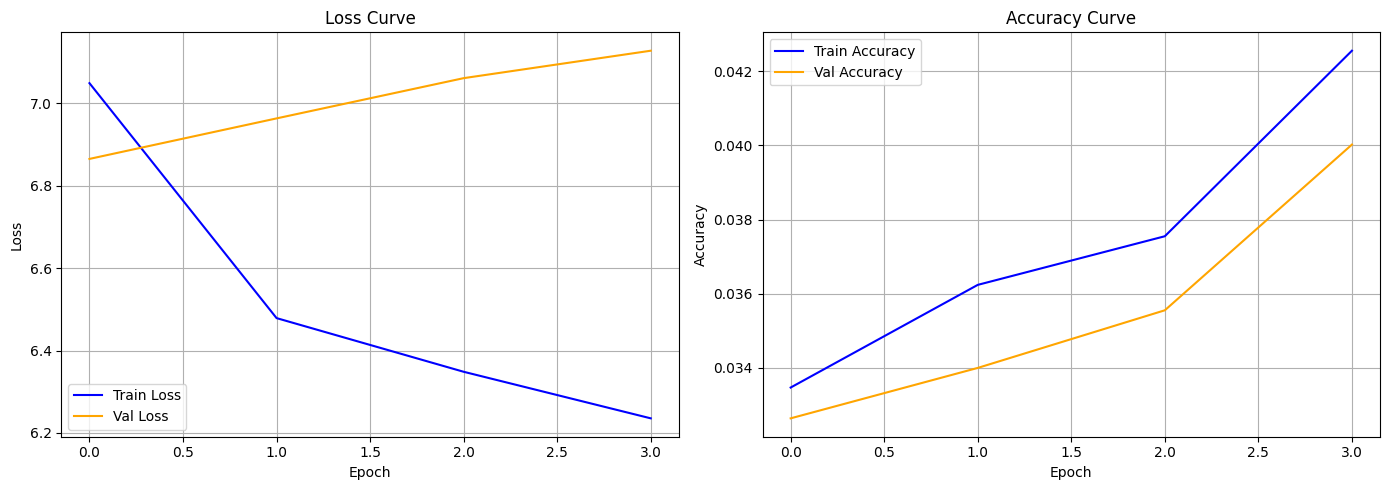

Best val_loss    : 6.8648
Best val_accuracy: 0.0400


In [ ]:
# plot training history to visualize overfitting
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history.history['loss'],     label='Train Loss', color='blue')
ax1.plot(history.history['val_loss'], label='Val Loss',   color='orange')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

print(f'Best val_loss    : {min(history.history["val_loss"]):.4f}')
print(f'Best val_accuracy: {max(history.history["val_accuracy"]):.4f}')

In [22]:
#  save the model
model.save('../Models/next_word_lstm.keras')

#  save the tokenizer

import pickle
with open('../Models/tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer,handle,protocol=pickle.HIGHEST_PROTOCOL)